**Necessary Libraries and Dependencies**

In [33]:
import numpy as np
import random
import scipy.io
from random import choices
import matplotlib.pyplot as plt

**Environment Defined as a Class**

In [34]:
# =============================================================================
# GridWorld Environment (no gym/gymnasium dependency)
# Replicates GridWorld_Fox2016 exactly
# =============================================================================

class GridWorldEnv:
    """
    8x8 GridWorld environment from Fox (2016).
    Terminal state: [4, 4] (index 36).
    Blocked (invalid) states: inv_state list below.

    Actions:
        0 - North       (row-1)
        1 - North-East  (row-1, col+1)
        2 - East        (col+1)
        3 - South-East  (row+1, col+1)
        4 - South       (row+1)
        5 - South-West  (row+1, col-1)
        6 - West        (col-1)
        7 - North-West  (row-1, col-1)
        8 - No change
    """

    def __init__(self):
        print('GridWorldEnv (Fox2016) Loaded...')
        self.state = None

        # Blocked grid cells
        self.inv_state = [
            [1,1], [1,4],
            [2,1], [2,4],
            [3,1], [3,4], [3,5], [3,6],
            [4,1], [4,2], [4,6],
            [5,2], [5,6],
            [6,2], [6,6]
        ]

        # Map: flat index -> (row, col)
        self.states_ind = {}
        k = 0
        for i in range(8):
            for j in range(8):
                self.states_ind[k] = (i, j)
                k += 1

        self.n_invalid = len(self.inv_state)

    # ------------------------------------------------------------------
    def _is_blocked(self, row, col):
        return [row, col] in self.inv_state

    def _is_out(self, row, col):
        return row < 0 or row > 7 or col < 0 or col > 7

    # ------------------------------------------------------------------
    def step(self, action):
        """
        Returns: (obs, cost, done, info)
            obs  : np.array([row, col])
            cost : float
            done : bool
            info : dict (empty)
        """
        row, col = self.state
        row_old, col_old = row, col
        done = False
        info = {}
        cost = 0
        sigma = 0.2

        # Already at terminal state
        if [row, col] == [4, 4]:
            return np.array([row, col]), cost, True, info

        # --- Apply chosen action ---
        deltas = {
            0: (-1,  0), 1: (-1,  1), 2: ( 0,  1), 3: ( 1,  1),
            4: ( 1,  0), 5: ( 1, -1), 6: ( 0, -1), 7: (-1, -1),
            8: ( 0,  0)
        }
        dr, dc = deltas[action]
        row += dr
        col += dc
        cost += 1
        cost += np.random.normal(0, sigma)
        # Check if terminal after intended move
        if [row, col] == [4, 4]:
            self.state = np.array([row, col])
            return self.state, cost, True, info

        # Revert if out-of-bounds or blocked
        if self._is_out(row, col) or self._is_blocked(row, col):
            row, col = row_old, col_old
            cost += 1000
            cost += np.random.normal(0, sigma)


        row_old, col_old = row, col  # save post-action position

        # --- Stochastic drift ---
        r = np.random.uniform(0.0, 1.0)
        if   r <= 0.050:               row -= 1
        elif r <= 0.075:               row -= 1; col += 1
        elif r <= 0.125:               col += 1
        elif r <= 0.150:               row += 1; col += 1
        elif r <= 0.200:               row += 1
        elif r <= 0.225:               row += 1; col -= 1
        elif r <= 0.275:               col -= 1
        elif r <= 0.300:               row -= 1; col -= 1
        # else r > 0.3 : no drift

        # Drift cost only applies when drift actually moves agent
        if (row, col) != (row_old, col_old):
            cost += 1
            cost += np.random.normal(0, sigma)


        # Check terminal after drift
        if [row, col] == [4, 4]:
            self.state = np.array([row, col])
            return self.state, cost, True, info

        # Revert drift if out-of-bounds or blocked (undo the +1 cost)
        if self._is_out(row, col) or self._is_blocked(row, col):
            row, col = row_old, col_old
            cost -= 1
            cost -= np.random.normal(0, sigma)

        self.state = np.array([row, col])
        return self.state, cost, done, info

    # ------------------------------------------------------------------
    def reset(self):
        """
        Randomly pick a valid (non-blocked, non-terminal) start state.
        Returns: np.array([row, col])
        """
        while True:
            idx = np.random.randint(64)
            row, col = self.states_ind[idx]
            if [row, col] not in self.inv_state and [row, col] != [4, 4]:
                break
        self.state = np.array([row, col])
        return self.state

    # ------------------------------------------------------------------
    def reset_previous(self, st):
        """Reset to a specific (row, col) state."""
        self.state = np.array(st)
        return self.state


**Building the transition function and the cost function**

In [35]:
# =============================================================================
# State/Action indexing (module-level, used by P/C matrices and post_main)
# =============================================================================

N1 = 8
S_size = 64

k = 0
states = {}
states_pr = {}
for i in range(N1):
    for j in range(N1):
        states[k] = (i, j)
        states_pr[(i, j)] = k
        k += 1

# Action deltas
actions = {
    0: (-1,  0), 1: (-1,  1), 2: ( 0,  1), 3: ( 1,  1),
    4: ( 1,  0), 5: ( 1, -1), 6: ( 0, -1), 7: (-1, -1),
    8: ( 0,  0)
}

S = np.linspace(0, 63, 64)
A = np.linspace(0,  8,  9)
P = np.zeros((np.size(S), np.size(S), np.size(A)))
C = np.zeros((np.size(S), np.size(S), np.size(A)))

# Invisible (blocked) states as flat indices
inv_st = np.array([9, 17, 25, 33, 34, 42, 50, 12, 20, 28, 29, 30, 38, 46, 54])

# =============================================================================
# Build transition model P and cost model C
# =============================================================================

for a in range(9):
    for s in range(64):
        if s in inv_st:
            continue
        s_0, s_1 = states[s]
        if s == 36:          # terminal state
            P[s, s, a] = 1
            C[s, s, a] = 0
            continue

        s_pr_0 = s_0 + actions[a][0]
        s_pr_1 = s_1 + actions[a][1]

        if a == 8:
            s_pr_0, s_pr_1, s_pr = s_0, s_1, s
            C[s_pr, s, a] = 1
        elif s_pr_0 < 0 or s_pr_0 > 7 or s_pr_1 < 0 or s_pr_1 > 7:
            s_pr_0, s_pr_1, s_pr = s_0, s_1, s
        else:
            s_pr = states_pr[(s_pr_0, s_pr_1)]
            if s_pr == 36:
                P[s_pr, s, a] = 1
                C[s_pr, s, a] = 1
                continue
            if s_pr in inv_st:
                s_pr_0, s_pr_1, s_pr = s_0, s_1, s

        s_pr_0_old, s_pr_1_old, s_pr_old = s_pr_0, s_pr_1, s_pr
        p = 0

        for i in range(8):
            s_pr_0 = s_pr_0_old + actions[i][0]
            s_pr_1 = s_pr_1_old + actions[i][1]
            if 0 <= s_pr_0 <= 7 and 0 <= s_pr_1 <= 7:
                s_pr = states_pr[(s_pr_0, s_pr_1)]
                if s_pr in inv_st:
                    P[s_pr, s, a] = 0
                else:
                    if abs(actions[i][0]) + abs(actions[i][1]) == 1:
                        P[s_pr, s, a] = 0.05;  p += 0.05
                        C[s_pr, s, a] = 2 if s_pr_old != s else 1
                    else:
                        P[s_pr, s, a] = 0.025; p += 0.025
                        C[s_pr, s, a] = 2 if s_pr_old != s else 1

        P[s_pr_old, s, a] += 1 - p
        C[s_pr_old,  s, a]  = 1

In [36]:
# =============================================================================
# Policy evaluation
# =============================================================================

def policy_eval(policy):
    AvC   = np.sum(np.multiply(P, C), axis=0)
    V     = np.zeros(np.size(S))
    alpha = 0.85
    V_old = np.inf
    for _ in range(500):
        tmp1  = np.tile(V, (1, np.size(S) * np.size(A)))
        tmp2  = tmp1.reshape((np.size(S), np.size(S), np.size(A)), order='F')
        tmp   = np.sum(np.multiply(P, tmp2), axis=0)
        V     = np.sum(np.multiply(policy, (AvC + alpha * tmp)), axis=1)
        if np.linalg.norm(V - V_old) / np.linalg.norm(V) < 1e-5:
            break
        V_old = V
    return V


# =============================================================================
# Learning algorithms: Entropy Regularized + Q-Learning
# =============================================================================

def post_main(env):

    # np.random.seed(0)
    alpha    = 1
    gamma    = 0.85
    beta_max = 7.0
    beta_min = 0.1
    tot_epi  = 1500
    beta_arr = np.arange(beta_min, beta_max, (beta_max - beta_min) / tot_epi)

    # State index lookup: (row,col) -> flat index
    d = {(i, j): i * 8 + j for i in range(8) for j in range(8)}

    Q_er      = np.zeros((64, 9))
    Q_learn   = np.zeros((64, 9))
    V_er      = np.zeros(64)
    mu        = (1/9) * np.ones((64, 9))
    mu_er     = (1/9) * np.ones((64, 9))
    mu_Q1     = (1/9) * np.ones((64, 9))
    mu_ER     = np.zeros((tot_epi, 64, 9))

    optimal = np.array([
        [4.4098, 3.8096, 3.8096, 3.8096, 3.8096, 4.4098, 4.9311, 5.3873],
        [4.4098,      0, 3.0288, 3.0288,      0, 4.4098, 4.9311, 5.3873],
        [4.8806,      0, 2.1455, 2.1455,      0, 5.0336, 5.0336, 5.4940],
        [5.2439,      0, 2.0294, 1.0000,      0,      0,      0, 5.1445],
        [4.9307,      0,      0, 1.0000,      0, 1.0000,      0, 4.7615],
        [4.4761, 4.4761,      0, 1.0000, 1.0000, 1.0000,      0, 4.3139],
        [4.3638, 3.7411,      0, 2.0988, 2.0988, 2.0988,      0, 3.7411],
        [4.3638, 3.7411, 3.0170, 3.0170, 3.0170, 3.0170, 3.0170, 3.7411]
    ])
    optimal2 = optimal.ravel()

    choice  = [1, 2]
    choice1 = list(range(9))

    V_ER        = np.zeros(tot_epi)
    V_Q         = np.zeros(tot_epi)
    V_ER_a      = np.zeros(tot_epi)
    V_Q_a       = np.zeros(tot_epi)
    V_ER_pr     = np.zeros(tot_epi)
    V_Qlearn_pr = np.zeros(tot_epi)

    for ep in range(tot_epi):

        obs = env.reset()
        s1, s2   = int(obs[0]), int(obs[1])
        s1_old, s2_old = s1, s2
        s_main   = d[(s1, s2)]
        s        = s_main

        if s1 == 4 and s2 == 4:
            continue

        beta    = beta_arr[ep]
        epsilon = 0.4

        count_er = np.ones((64, 9))
        count_q  = np.ones((64, 9))

        # ---- Entropy Regularised ----
        env.reset_previous((s1_old, s2_old))
        s    = s_main
        itr1 = 0
        epsilon = 0.4

        while itr1 < 300:
            ep_choice = random.choices(choice, [epsilon, 1 - epsilon])[0]
            a = random.choices(choice1, mu_er[s, :])[0] if ep_choice == 2 else np.random.randint(0, 9)
            count_er[s, a] += 1

            obs, cost, done, info = env.step(a)
            s1, s2 = int(obs[0]), int(obs[1])
            s_pr   = d[(s1, s2)]

            Q_er[s, a] += ((1 / count_er[s, a]) ** 0.8) * alpha * (cost + gamma * V_er[s_pr] - Q_er[s, a])
            Q_min = np.min(Q_er[s, :])
            V_er[s] = (-1 / beta) * (-beta * Q_min + np.log(np.sum(np.exp(-beta * (Q_er[s, :] - Q_min)))))
            exp_vals = np.exp(-beta * (Q_er[s, :] - Q_min))
            mu_er[s, :] = exp_vals / np.sum(exp_vals)

            s        = s_pr
            itr1    += 1
            epsilon *= 0.9
            if done:
                break

        mu_ER[ep, :, :] = mu_er

        # ---- Q-Learning ----
        env.reset_previous((s1_old, s2_old))
        s    = s_main
        itr2 = 0
        epsilon = 0.4

        while itr2 < 300:
            ep_choice = random.choices(choice, [epsilon, 1 - epsilon])[0]
            a = random.choices(choice1, mu_Q1[s, :])[0] if ep_choice == 2 else np.random.randint(0, 9)
            count_q[s, a] += 1

            obs, cost, done, info = env.step(a)
            s1, s2 = int(obs[0]), int(obs[1])
            s_pr   = d[(s1, s2)]

            a_pr = np.argmin(Q_learn[s_pr, :])
            Q_learn[s, a] += ((1 / count_q[s, a]) ** 0.8) * alpha * (cost + gamma * Q_learn[s_pr, a_pr] - Q_learn[s, a])

            Q_min = np.min(Q_learn[s, :])
            exp_vals = np.exp(-beta * (Q_learn[s, :] - Q_min))
            if np.any(np.isinf(exp_vals)):
                mu_Q1[s, :] = 0
                mu_Q1[s, np.argmin(Q_learn[s, :])] = 1
            else:
                mu_Q1[s, :] = exp_vals / np.sum(exp_vals)

            s        = s_pr
            itr2    += 1
            epsilon *= 0.9
            if done:
                break

        # ---- Policy Evaluation ----
        V_er_pr = policy_eval(mu_er)
        V_Q_pr  = policy_eval(mu_Q1)

        for st in range(64):
            if st in inv_st or st == 36:
                continue
            V_ER[ep]        += (1/64) * ((V_er[st]            - optimal2[st]) / optimal2[st])
            V_Q[ep]         += (1/64) * ((min(Q_learn[st, :]) - optimal2[st]) / optimal2[st])
            V_ER_a[ep]      += (1/64) * abs((V_er[st]            - optimal2[st]) / optimal2[st])
            V_Q_a[ep]       += (1/64) * abs((min(Q_learn[st, :]) - optimal2[st]) / optimal2[st])
            V_ER_pr[ep]     += (1/64) * abs((V_er_pr[st]          - optimal2[st]) / optimal2[st])
            V_Qlearn_pr[ep] += (1/64) * abs((V_Q_pr[st]           - optimal2[st]) / optimal2[st])

    return V_ER, V_Q, V_ER_a, V_Q_a, V_ER_pr, V_Qlearn_pr

In [37]:
# Function to plot the curves
'''def plot_results(V_ER, V_Q, V_ER_a, V_Q_a, V_ER_pr, V_Qlearn_pr):

    tot_epi, runs = V_ER.shape
    episodes = np.arange(tot_epi)

    # If multiple runs, average them
    if runs > 1:
        V_ER_plot = np.mean(V_ER, axis=1)
        V_Q_plot = np.mean(V_Q, axis=1)

        V_ER_a_plot = np.mean(V_ER_a, axis=1)
        V_Q_a_plot = np.mean(V_Q_a, axis=1)

        V_ER_pr_plot = np.mean(V_ER_pr, axis=1)
        V_Qlearn_pr_plot = np.mean(V_Qlearn_pr, axis=1)
    else:
        V_ER_plot = V_ER[:,0]
        V_Q_plot = V_Q[:,0]

        V_ER_a_plot = V_ER_a[:,0]
        V_Q_a_plot = V_Q_a[:,0]

        V_ER_pr_plot = V_ER_pr[:,0]
        V_Qlearn_pr_plot = V_Qlearn_pr[:,0]

    # ---------------------------
    # Plot 1 : Signed Relative Error
    # ---------------------------

    plt.figure(figsize=(7,5))
    plt.plot(episodes, V_ER_plot, label="Entropy RL")
    plt.plot(episodes, V_Q_plot, label="Q-Learning")

    plt.xlabel("Episode")
    plt.ylabel("Relative Error")
    plt.title(f"Signed Relative Error vs Episode {runs}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------------------------
    # Plot 2 : Absolute Error
    # ---------------------------

    plt.figure(figsize=(7,5))
    plt.plot(episodes, V_ER_a_plot, label="Entropy RL")
    plt.plot(episodes, V_Q_a_plot, label="Q-Learning")

    plt.xlabel("Episode")
    plt.ylabel("Absolute Relative Error")
    plt.title(f"Absolute Error vs Episode {runs}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------------------------
    # Plot 3 : Policy Evaluation Error
    # ---------------------------

    plt.figure(figsize=(7,5))
    plt.plot(episodes, V_ER_pr_plot, label="Entropy RL Policy")
    plt.plot(episodes, V_Qlearn_pr_plot, label="Q-Learning Policy")

    plt.xlabel("Episode")
    plt.ylabel("Policy Evaluation Error")
    plt.title(f"Policy Evaluation Error vs Episode {runs}")
    plt.legend()
    plt.grid(True)
    plt.show()'''

def plot_results(V_ER, V_Q, V_ER_a, V_Q_a, V_ER_pr, V_Qlearn_pr):
    tot_epi, runs = V_ER.shape
    episodes = np.arange(tot_epi)

    # --- Data Processing (Averaging) ---
    def get_plot_data(data):
        return np.mean(data, axis=1) if runs > 1 else data[:, 0]

    v_er_p = get_plot_data(V_ER)
    v_q_p  = get_plot_data(V_Q)
    v_er_a_p = get_plot_data(V_ER_a)
    v_q_a_p  = get_plot_data(V_Q_a)
    v_er_pr_p = get_plot_data(V_ER_pr)
    v_q_pr_p  = get_plot_data(V_Qlearn_pr)

    # --- Create the Subplots Layout ---
    # figsize=(18, 5) makes it wide enough to fit three plots side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Define a shared style for all plots
    labels = ["Entropy RL", "Q-Learning"]

    # 1. Signed Relative Error
    axes[0].plot(episodes, v_er_p, label=labels[0])
    axes[0].plot(episodes, v_q_p, label=labels[1])
    axes[0].set_title(f"Signed Relative Error (Runs: {runs})")
    axes[0].set_ylabel("Relative Error")

    # 2. Absolute Error
    axes[1].plot(episodes, v_er_a_p, label=labels[0])
    axes[1].plot(episodes, v_q_a_p, label=labels[1])
    axes[1].set_title(f"Absolute Error (Runs: {runs})")
    axes[1].set_ylabel("Absolute Relative Error")

    # 3. Policy Evaluation Error
    axes[2].plot(episodes, v_er_pr_p, label="Entropy RL Policy")
    axes[2].plot(episodes, v_q_pr_p, label="Q-Learning Policy")
    axes[2].set_title(f"Policy Evaluation Error (Runs: {runs})")
    axes[2].set_ylabel("Error Value")

    # --- Global Formatting ---
    for ax in axes:
        ax.set_xlabel("Episode")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)

    # This prevents the labels of one plot from overlapping with the next
    plt.tight_layout()
    plt.show()

GridWorldEnv (Fox2016) Loaded...
Run # 0
Done. Gadbad count: 0


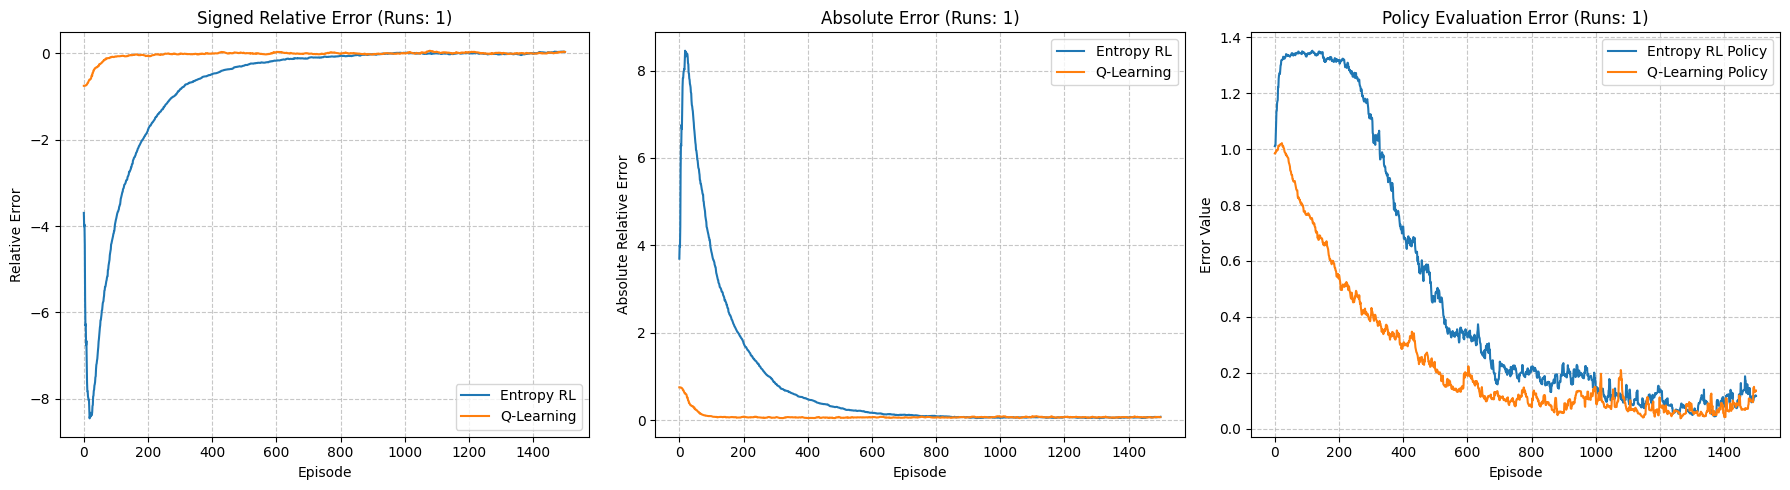

In [38]:
def main_single():
    #np.random.seed(0)
    env     = GridWorldEnv()       # ← pure Python, no gym needed
    runs       = 1
    tot_epi = 1500
    count   = 0

    V_ER        = np.zeros((tot_epi, runs))
    V_Q         = np.zeros((tot_epi, runs))
    V_ER_a      = np.zeros((tot_epi, runs))
    V_Q_a       = np.zeros((tot_epi, runs))
    V_ER_pr     = np.zeros((tot_epi, runs))
    V_Qlearn_pr = np.zeros((tot_epi, runs))

    for i in range(runs):
        print('Run #', i)
        V_ER[:, i], V_Q[:, i], V_ER_a[:, i], V_Q_a[:, i], \
        V_ER_pr[:, i], V_Qlearn_pr[:, i] = post_main(env)

        if np.isnan(np.min(V_ER[:, i])) or np.isnan(np.min(V_Q[:, i])):
            V_ER[:, i]    = 0
            V_Q[:, i]     = 0
            V_ER_a[:, i]  = 0
            V_Q_a[:, i]   = 0
            count += 1
            print('Gadbad')

    '''print(
        "V_ER:",V_ER,
        "\nV_Q:",V_Q,
        "\nV_ER_a:",V_ER_a,
        "\nV_Q_a:", V_Q_a,
        "\nV_ER_pr:",V_ER_pr,
        "\nV_Qlearn_pr:",V_Qlearn_pr
    )'''
    print(f'Done. Gadbad count: {count}')
    plot_results(V_ER, V_Q, V_ER_a, V_Q_a, V_ER_pr, V_Qlearn_pr)

main_single()


GridWorldEnv (Fox2016) Loaded...
Run # 0
Run # 1
Run # 2
Run # 3
Run # 4
Run # 5
Run # 6
Run # 7
Run # 8
Run # 9
Done. Gadbad count: 0


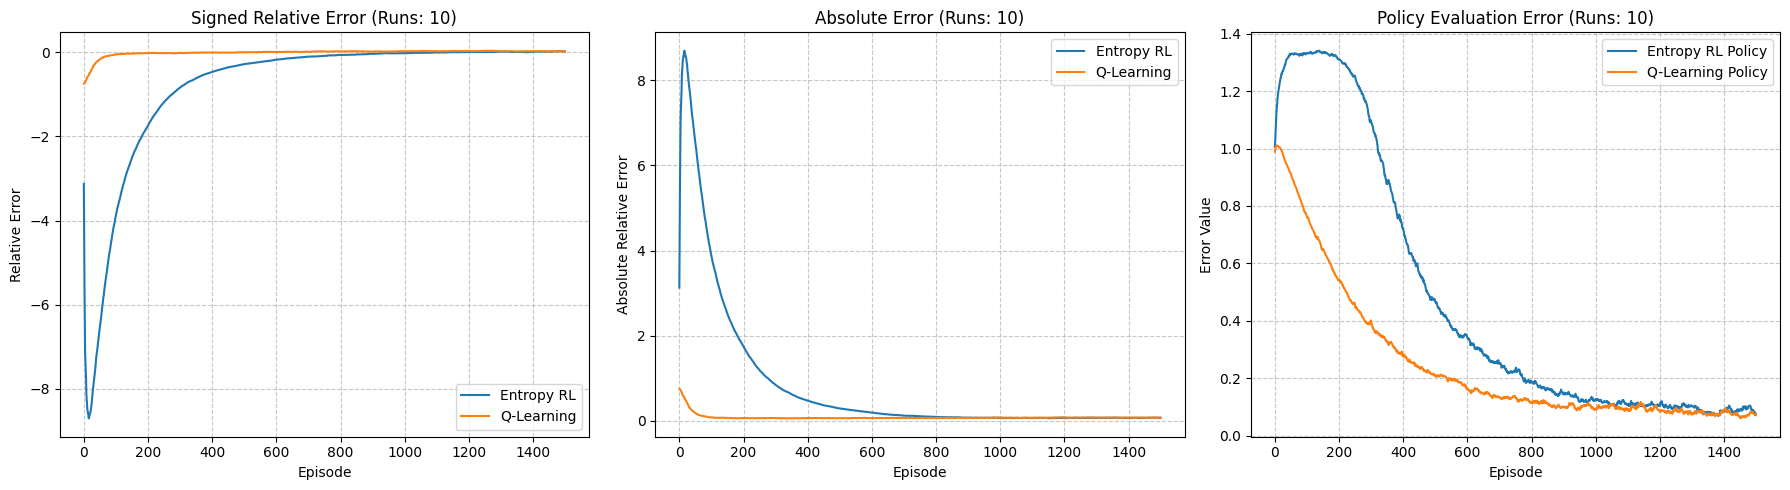

In [39]:



# =============================================================================
# Main
# =============================================================================

def main_multiple():
    #np.random.seed(0)
    env     = GridWorldEnv()       # ← pure Python, no gym needed
    runs       = 10
    tot_epi = 1500
    count   = 0

    V_ER        = np.zeros((tot_epi, runs))
    V_Q         = np.zeros((tot_epi, runs))
    V_ER_a      = np.zeros((tot_epi, runs))
    V_Q_a       = np.zeros((tot_epi, runs))
    V_ER_pr     = np.zeros((tot_epi, runs))
    V_Qlearn_pr = np.zeros((tot_epi, runs))

    for i in range(runs):
        print('Run #', i)
        V_ER[:, i], V_Q[:, i], V_ER_a[:, i], V_Q_a[:, i], \
        V_ER_pr[:, i], V_Qlearn_pr[:, i] = post_main(env)

        if np.isnan(np.min(V_ER[:, i])) or np.isnan(np.min(V_Q[:, i])):
            V_ER[:, i]    = 0
            V_Q[:, i]     = 0
            V_ER_a[:, i]  = 0
            V_Q_a[:, i]   = 0
            count += 1
            print('Gadbad')

    '''print(
        "V_ER:",V_ER,
        "\nV_Q:",V_Q,
        "\nV_ER_a:",V_ER_a,
        "\nV_Q_a:", V_Q_a,
        "\nV_ER_pr:",V_ER_pr,
        "\nV_Qlearn_pr:",V_Qlearn_pr
    )'''
    print(f'Done. Gadbad count: {count}')
    plot_results(V_ER, V_Q, V_ER_a, V_Q_a, V_ER_pr, V_Qlearn_pr)


main_multiple()

